In [11]:
import torch
import numpy as np
from tqdm.auto import tqdm
import lovely_tensors as lt
lt.monkey_patch()
import matplotlib.pyplot as plt

In [12]:
import os, sys
sys.path.append('/home/ubuntu/repos/normative-diffusion')
os.chdir('/home/ubuntu/repos/normative-diffusion')

In [4]:
from accelerate import Accelerator, DistributedDataParallelKwargs
from sklearn.metrics import average_precision_score

from diffusion import *
from modules import *
from utils import *


In [4]:
# add manual argparse without any command line arguments
class BraTSArgs:
    dataset_path = 'data/brats'
    path_to_csv = 'data/brats/splits/scans_test.csv'
    batch_size = 1
    image_size = 128

class ShiftsArgs:
    dataset_path = 'data/shifts_registered/patients'
    path_to_csv = 'data/shifts_registered/shifts_in.csv'
    batch_size = 1
    image_size = 128

bratsargs = BraTSArgs()
shiftsargs = ShiftsArgs()

args = bratsargs # to get brats datapoint

In [5]:
from scipy.interpolate import interp1d

def match_histograms(source, template):
    """
    Adjust the pixel values of a 3D image such that its histogram
    matches that of a target image
    
    Parameters:
    - source (np.ndarray): Source image, specified as a 3D numpy array.
    - template (np.ndarray): Template image with the desired histogram, specified as a 3D numpy array.
    
    Returns:
    - matched (np.ndarray): The source image after histogram matching to the template image.
    """
    # Flatten the source and template images to 1D arrays
    source_values = source.ravel()
    template_values = template.ravel()

    # Compute the histograms of the source and the template images
    s_values, bin_idx, s_counts = np.unique(source_values, return_inverse=True, return_counts=True)
    t_values, t_counts = np.unique(template_values, return_counts=True)
    
    # Calculate the cumulative distribution function for the source and template
    s_quantiles = np.cumsum(s_counts).astype(np.float64)
    s_quantiles /= s_quantiles[-1]
    t_quantiles = np.cumsum(t_counts).astype(np.float64)
    t_quantiles /= t_quantiles[-1]

    # Interpolate to find the pixel values in the template image
    # that correspond to the quantiles in the source image
    interp_t_values = np.interp(s_quantiles, t_quantiles, t_values)

    # Map the source image pixels to the template pixels
    matched = interp_t_values[bin_idx].reshape(source.shape)
    
    return matched

def match_histograms_vectorized(source, template):
    """
    Adjust the pixel values of a batch of 3D images such that the histogram of each
    modality matches that of the corresponding modality in the template batch.

    Parameters:
    - source (np.ndarray): Source batch, specified as a 5D numpy array with dimensions
      [batch_size, modality_channel, Depth, Height, Width].
    - template (np.ndarray): Template batch with the desired histograms, specified as a
      5D numpy array with the same dimensions as the source.

    Returns:
    - matched (np.ndarray): The source batch after histogram matching to the template batch.
    """
    # Initialize the matched array with the same shape as the source
    matched = np.empty_like(source)

    # Iterate over each modality
    for modality in range(source.shape[1]):
        # Extract the current modality volumes from source and template
        source_modality = source[:, modality, ...].reshape(source.shape[0], -1)
        template_modality = template[:, modality, ...].reshape(template.shape[0], -1)
        
        # Perform histogram matching for each volume in the batch for the current modality
        for i in range(source.shape[0]):
            s_values, bin_idx, s_counts = np.unique(source_modality[i], return_inverse=True, return_counts=True)
            t_values, t_counts = np.unique(template_modality[i], return_counts=True)

            s_quantiles = np.cumsum(s_counts).astype(np.float64)
            s_quantiles /= s_quantiles[-1]
            t_quantiles = np.cumsum(t_counts).astype(np.float64)
            t_quantiles /= t_quantiles[-1]

            interp_t_values = np.interp(s_quantiles, t_quantiles, t_values)
            matched[i, modality, ...] = interp_t_values[bin_idx].reshape(source.shape[2], source.shape[3], source.shape[4])

    return matched


In [5]:
dataloader = MRI_Volume(bratsargs, hist=False, shift=False)
brats_vol = next(iter(dataloader))

dataloader = MRI_Volume(shiftsargs, hist=False, shift=True)
shifts_vol = next(iter(dataloader))

# save (brats_vol, shifts_vol) to disk
# torch.save((brats_vol[0], shifts_vol[0]), 'data/brats_shifts.pt')
brats_vol, shifts_vol = brats_vol[0], shifts_vol[0]
template, source = brats_vol, shifts_vol



Template shape: torch.Size([1, 4, 128, 128, 155]) Source shape: torch.Size([1, 4, 128, 128, 155])


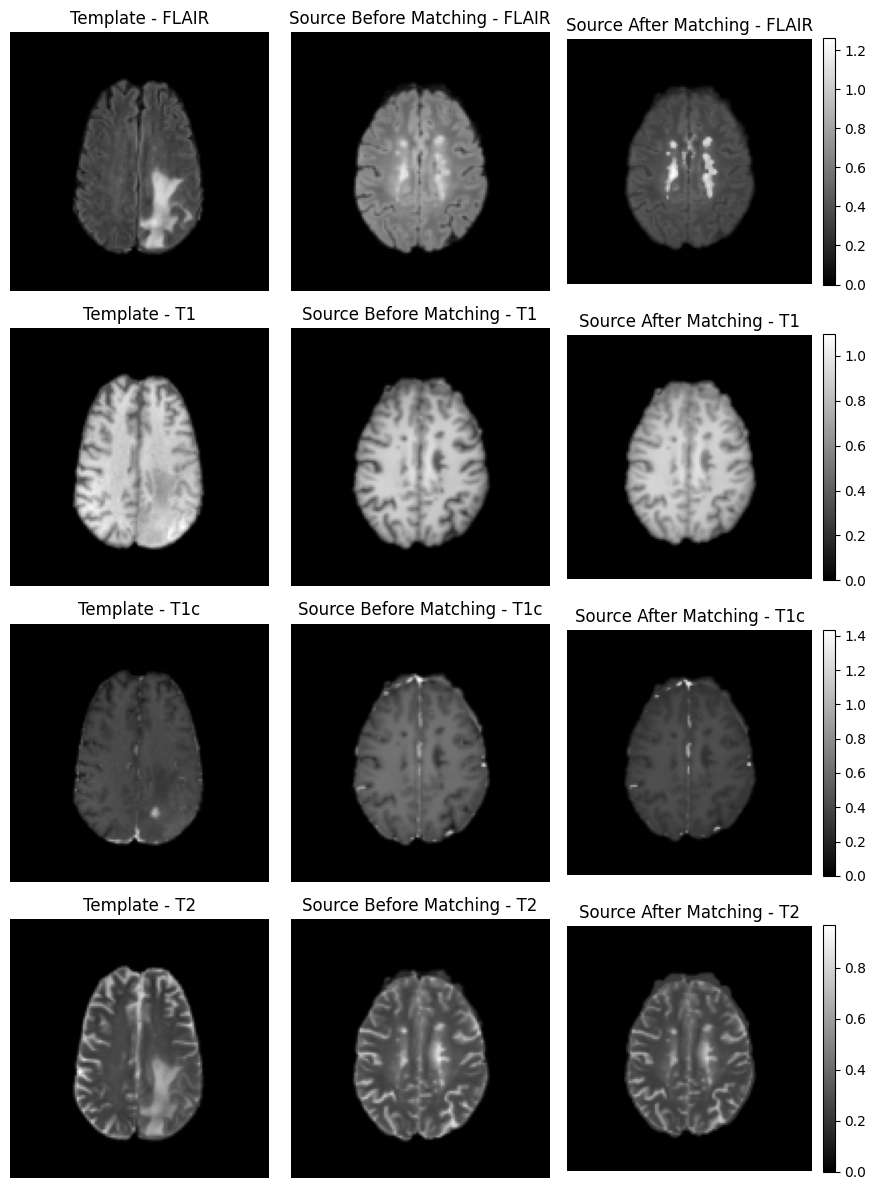

In [7]:

def plot_all_modalities(template, source, matched, slice_index, add_colorbar=True):
    """
    Plots slices of the template, source before matching, and source after matching for all modalities.
    Each modality has its own vmin and vmax for image scaling.
    Optionally adds a colorbar to the plots.

    Parameters:
    - template: The template 5D tensor.
    - source: The source 5D tensor before matching.
    - matched: The source 5D tensor after matching.
    - slice_index: Index of the slice to plot.
    - add_colorbar: Boolean, whether to add a colorbar to the plots.
    """
    modality_names = ['FLAIR', 'T1', 'T1c', 'T2']
    num_modalities = template.shape[1]
    fig, axes = plt.subplots(num_modalities, 3, figsize=(9, 3 * num_modalities))

    # Calculate vmin and vmax for each modality
    vmin_vmax = []
    for modality_index in range(num_modalities):
        modality_slice = slice_index
        vmin = min(template[0, modality_index, :, :, modality_slice].min(),
                   source[0, modality_index, :, :, modality_slice].min(),
                   matched[0, modality_index, :, :, modality_slice].min())
        vmax = max(template[0, modality_index, :, :, modality_slice].max(),
                   source[0, modality_index, :, :, modality_slice].max(),
                   matched[0, modality_index, :, :, modality_slice].max())
        vmin_vmax.append((vmin, vmax))

    # Define a helper function to plot an image
    def plot_image(ax, image, title, modality_index, vmin, vmax, last=False):
        im = ax.imshow(image[0, modality_index, :, :, slice_index].T, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(f'{title} - {modality_names[modality_index]}')
        ax.axis('off')
        if add_colorbar and last:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Plot for each modality
    for modality_index in range(num_modalities):
        vmin, vmax = vmin_vmax[modality_index]
        plot_image(axes[modality_index][0], template, 'Template', modality_index, vmin, vmax)
        plot_image(axes[modality_index][1], source, 'Source Before Matching', modality_index, vmin, vmax)
        plot_image(axes[modality_index][2], matched, 'Source After Matching', modality_index, vmin, vmax, last=True)

    plt.tight_layout()
    fig.subplots_adjust(wspace=0.05)
    # plt.show()

# Extract the first template and source tensor pair
template, source = brats_vol, shifts_vol
print('Template shape: {}'.format(template.shape), 'Source shape: {}'.format(source.shape))
modality_index = 0  # First modality for demonstration
slice_index = 100  # Last slice in the depth dimension

# Perform histogram matching on the extracted pair
matched = match_histograms_vectorized(source.numpy(), template.numpy())

# Plot the slices
plot_all_modalities(template, source, matched, slice_index)

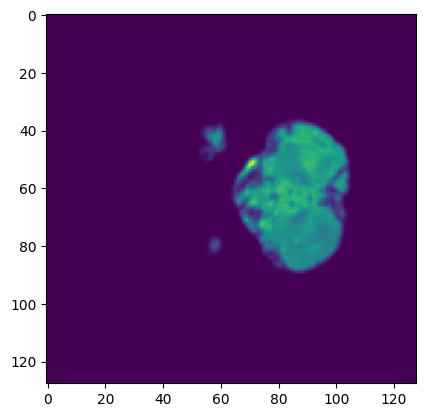

In [14]:
plt.imshow(shifts_vol[0,0,:,:,30])

In [17]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

# Make sure to import or define your template, source, and matched tensors before running this

# Refactored function that updates the figure and axes
def update_plot_all_modalities(fig, axes, template, source, matched, slice_index, vmin_vmax, add_colorbar=True):
    modality_names = ['FLAIR', 'T1', 'T1c', 'T2']
    num_modalities = template.shape[1]

    # Clear the axes to prepare for the new frame
    for ax_row in axes:
        for ax in ax_row:
            ax.cla()

    # Helper function to plot an image
    def plot_image(ax, image, title, modality_index, vmin, vmax, last=False):
        im = ax.imshow(image[0, modality_index, :, :, slice_index].T, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(f'{title} - {modality_names[modality_index]}')
        ax.axis('off')
        if add_colorbar and last:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        return im

    # Update plots for each modality
    for modality_index in range(num_modalities):
        vmin, vmax = vmin_vmax[modality_index]
        plot_image(axes[modality_index][0], template, 'Template', modality_index, vmin, vmax)
        plot_image(axes[modality_index][1], source, 'Source Before Matching', modality_index, vmin, vmax)
        plot_image(axes[modality_index][2], matched, 'Source After Matching', modality_index, vmin, vmax, last=True)

    fig.tight_layout()

# Create figure and axes outside the function
num_modalities = template.shape[1]
fig, axes = plt.subplots(num_modalities, 3, figsize=(9, 3 * num_modalities))
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Precompute vmin and vmax for each modality and slice
vmin_vmax = [
    (
        min(template[0, i, :, :, :].min(), source[0, i, :, :, :].min(), matched[0, i, :, :, :].min()),
        max(template[0, i, :, :, :].max(), source[0, i, :, :, :].max(), matched[0, i, :, :, :].max())
    )
    for i in range(num_modalities)
]

# Function to update each frame of the animation
def update(frame_index):
    update_plot_all_modalities(fig, axes, template, source, matched, frame_index, vmin_vmax, add_colorbar=False)

# Create the animation
ani = FuncAnimation(fig, update, frames=range(155), interval=50)

# Save the animation
ani.save('modalities_animation.mp4', writer='ffmpeg', dpi=300)

# Close the figure to prevent it from displaying statically
plt.close(fig)


In [6]:
kwargs = DistributedDataParallelKwargs(find_unused_parameters=True)
accelerator = Accelerator(kwargs_handlers=[kwargs])
device = accelerator.device
model = UNet().to(device=device)
# ckpt = torch.load(
#     "data/brats/models/DDPM-Gauss/232_ema_ckpt.pt" # Gaussian noise
#     # "data/brats/models/DDPM-Pyramid/232_ema_ckpt.pt" # Pyramidal noise
# )

# model.load_state_dict(ckpt)
# model.eval()
args = bratsargs
diffusion = Diffusion(noise_steps=1000, img_size=128, device=device)
dataloader = MRI_Volume(args, hist=False, shift=False)
dataloader = accelerator.prepare(dataloader)


In [9]:
MODEL_TYPE = ['DDPM-Gauss', 'DDPM-Pyramid'][::-1]
PYRAMID_FORWARD_NOISE = [False, True][::-1]
SKIP_DIFF = [False, True]
SKIP_NUM = [2, 5, 10, 25, 50, 100, 200, 500]

from itertools import product

zs_list_dict = {}
real_chain_list_dict = {}
pred_chain_list_dict = {}

for skip_diff, model_type, pyramid_forward_noise in tqdm(product(SKIP_DIFF, MODEL_TYPE, PYRAMID_FORWARD_NOISE), desc='outer product'):
    print(f"skip_diff: {skip_diff}, model_type: {model_type}, pyramid_forward_noise: {pyramid_forward_noise}")
    zs_list = []
    real_chain_list = []
    pred_chain_list = []
    ckpt = torch.load(
    f"data/brats/models/{model_type}/232_ema_ckpt.pt"
    )
    model.load_state_dict(ckpt)
    model.eval()
    with torch.no_grad():
        for i, (image, label) in tqdm(enumerate(dataloader), total=len(dataloader), desc='dataloader loop'):
            image = torch.from_numpy(match_histograms_vectorized(image.cpu().numpy(), template.numpy())).to(device).float()
            image = (image * 2) - 1
            # num_steps = 200
            size_splits = 20
            num_volumes = image.shape[0]
            num_slices = image.shape[4]
            image = torch.permute(image, (0, 4, 1, 2, 3))
            image = image.view(-1, image.shape[2], image.shape[3], image.shape[4])
            splits = torch.split(image, size_splits)
            chunks = []
            for split_tensor in tqdm(splits, total=len(splits), desc='split loop'):
                if not skip_diff:
                    real_chain, pred_chain = diffusion.dpm_differences(model, split_tensor, start = 0, stop = 300, pyramid=pyramid_forward_noise, return_chain=True)
                    real_chain, pred_chain = real_chain.to('cpu'), pred_chain.to('cpu')
                else:
                    real_chain, pred_chain = diffusion.skip_differences(model, split_tensor, start = 0, stop = 300, skip=25, pyramid=pyramid_forward_noise, return_chain=True)
                    real_chain, pred_chain = real_chain.to('cpu'), pred_chain.to('cpu')
                chunks.append([real_chain, pred_chain])
            # zs = torch.cat([chunk[0] for chunk in chunks], dim=0)
            real_chain = torch.cat([chunk[0] for chunk in chunks], dim=0)
            pred_chain = torch.cat([chunk[1] for chunk in chunks], dim=0)
            # zs_list.append(zs)
            real_chain_list.append(real_chain)
            pred_chain_list.append(pred_chain)
            break # only 1 datapoint

    zs_list_dict[(skip_diff, model_type, pyramid_forward_noise)] = zs_list
    real_chain_list_dict[(skip_diff, model_type, pyramid_forward_noise)] = real_chain_list
    pred_chain_list_dict[(skip_diff, model_type, pyramid_forward_noise)] = pred_chain_list

    break # only 1 config



outer product: 0it [00:00, ?it/s]

skip_diff: False, model_type: DDPM-Pyramid, pyramid_forward_noise: False


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]


dataloader loop:   0%|          | 0/52 [01:39<?, ?it/s]
outer product: 0it [01:40, ?it/s]


In [40]:
real_chain = torch.cat([chunk[0] for chunk in chunks], dim=0)
pred_chain = torch.cat([chunk[1] for chunk in chunks], dim=0)
# zs_list.append(zs)
real_chain_list.append(real_chain)
pred_chain_list.append(pred_chain)

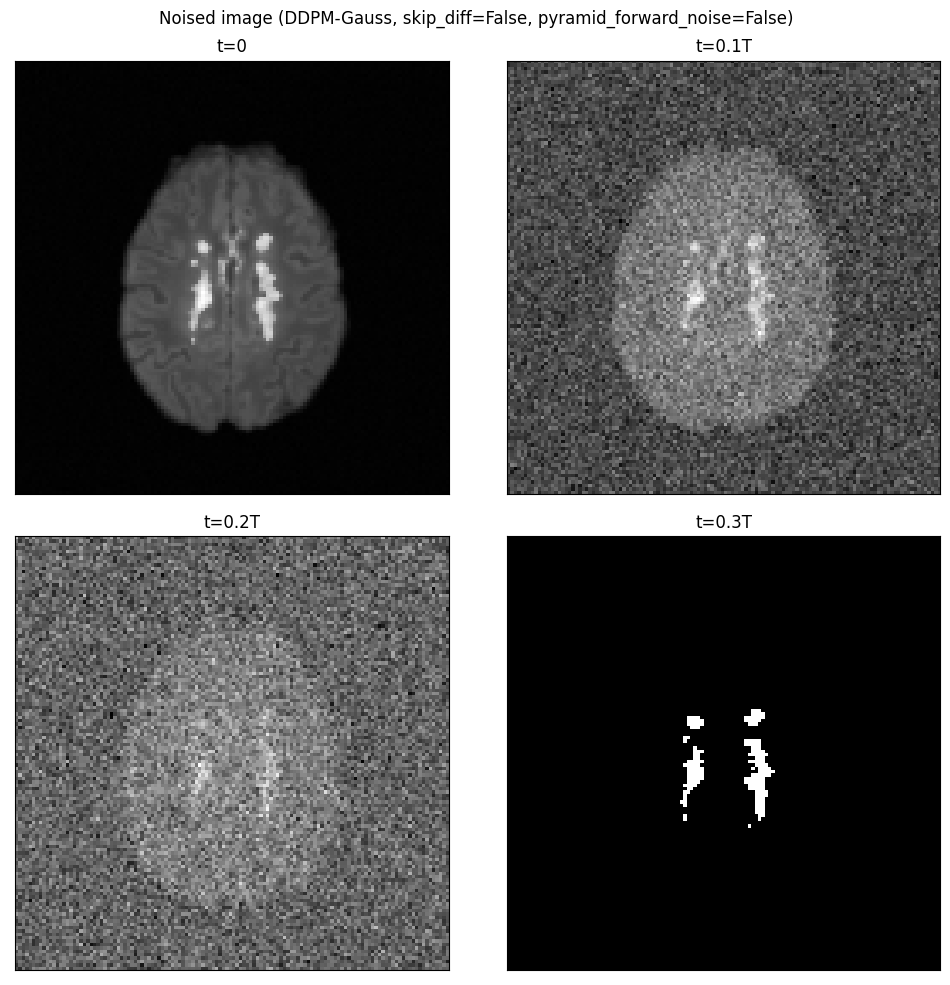

In [10]:


slice_loc = 100

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.imshow(real_chain[slice_loc, 0, 0, :, :].T, cmap='gray')
plt.title('t=0')
plt.xticks([])
plt.yticks([])


plt.subplot(2, 2, 2)
plt.imshow(real_chain[slice_loc, 100, 0, :, :].T, cmap='gray')
plt.title('t=0.1T')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 2, 3)
plt.imshow(real_chain[slice_loc, 200, 0, :, :].T, cmap='gray')
plt.title('t=0.2T')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 2, 4)
plt.imshow(label.cpu()[0,:,:,slice_loc].T, cmap='gray')
plt.title('t=0.3T')
plt.xticks([])
plt.yticks([])

# suptitle
plt.suptitle('Noised image (DDPM-Gauss, skip_diff=False, pyramid_forward_noise=False)')
plt.tight_layout()


In [ ]:
from matplotlib.animation import FuncAnimation


# Function to update the plots for each frame
def update_plot(frame_number, real_chain, label, fig, axes):
    slice_loc = frame_number
    axes[0].imshow(real_chain[slice_loc, 0, 0, :, :].T, cmap='gray')
    axes[1].imshow(real_chain[slice_loc, 100, 0, :, :].T, cmap='gray')
    axes[2].imshow(real_chain[slice_loc, 200, 0, :, :].T, cmap='gray')
    axes[3].imshow(label.cpu()[0, :, :, slice_loc].T, cmap='gray')
    
    for i, ax in enumerate(axes):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f't={i * 0.1:.1f}T')

    fig.suptitle('Noised image (DDPM-Gauss, skip_diff=False, pyramid_forward_noise=False)')


# Create a figure and a set of subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()  # Flatten the 2x2 array of axes for easy indexing

# Creating the animation
ani = FuncAnimation(fig, update_plot, frames=np.arange(50, 120), fargs=(real_chain, label, fig, axes))

# Save the animation as an mp4 file
ani.save('noised_image_animation.mp4', writer='ffmpeg', dpi=80)

# Display the animation in the Jupyter notebook
plt.close(fig)  # Prevents duplicate display of the last frame
from IPython.display import Video
Video('noised_image_animation.mp4')

torch.Size([299, 128, 128]) torch.Size([299])
torch.Size([299, 128, 128]) torch.Size([299])


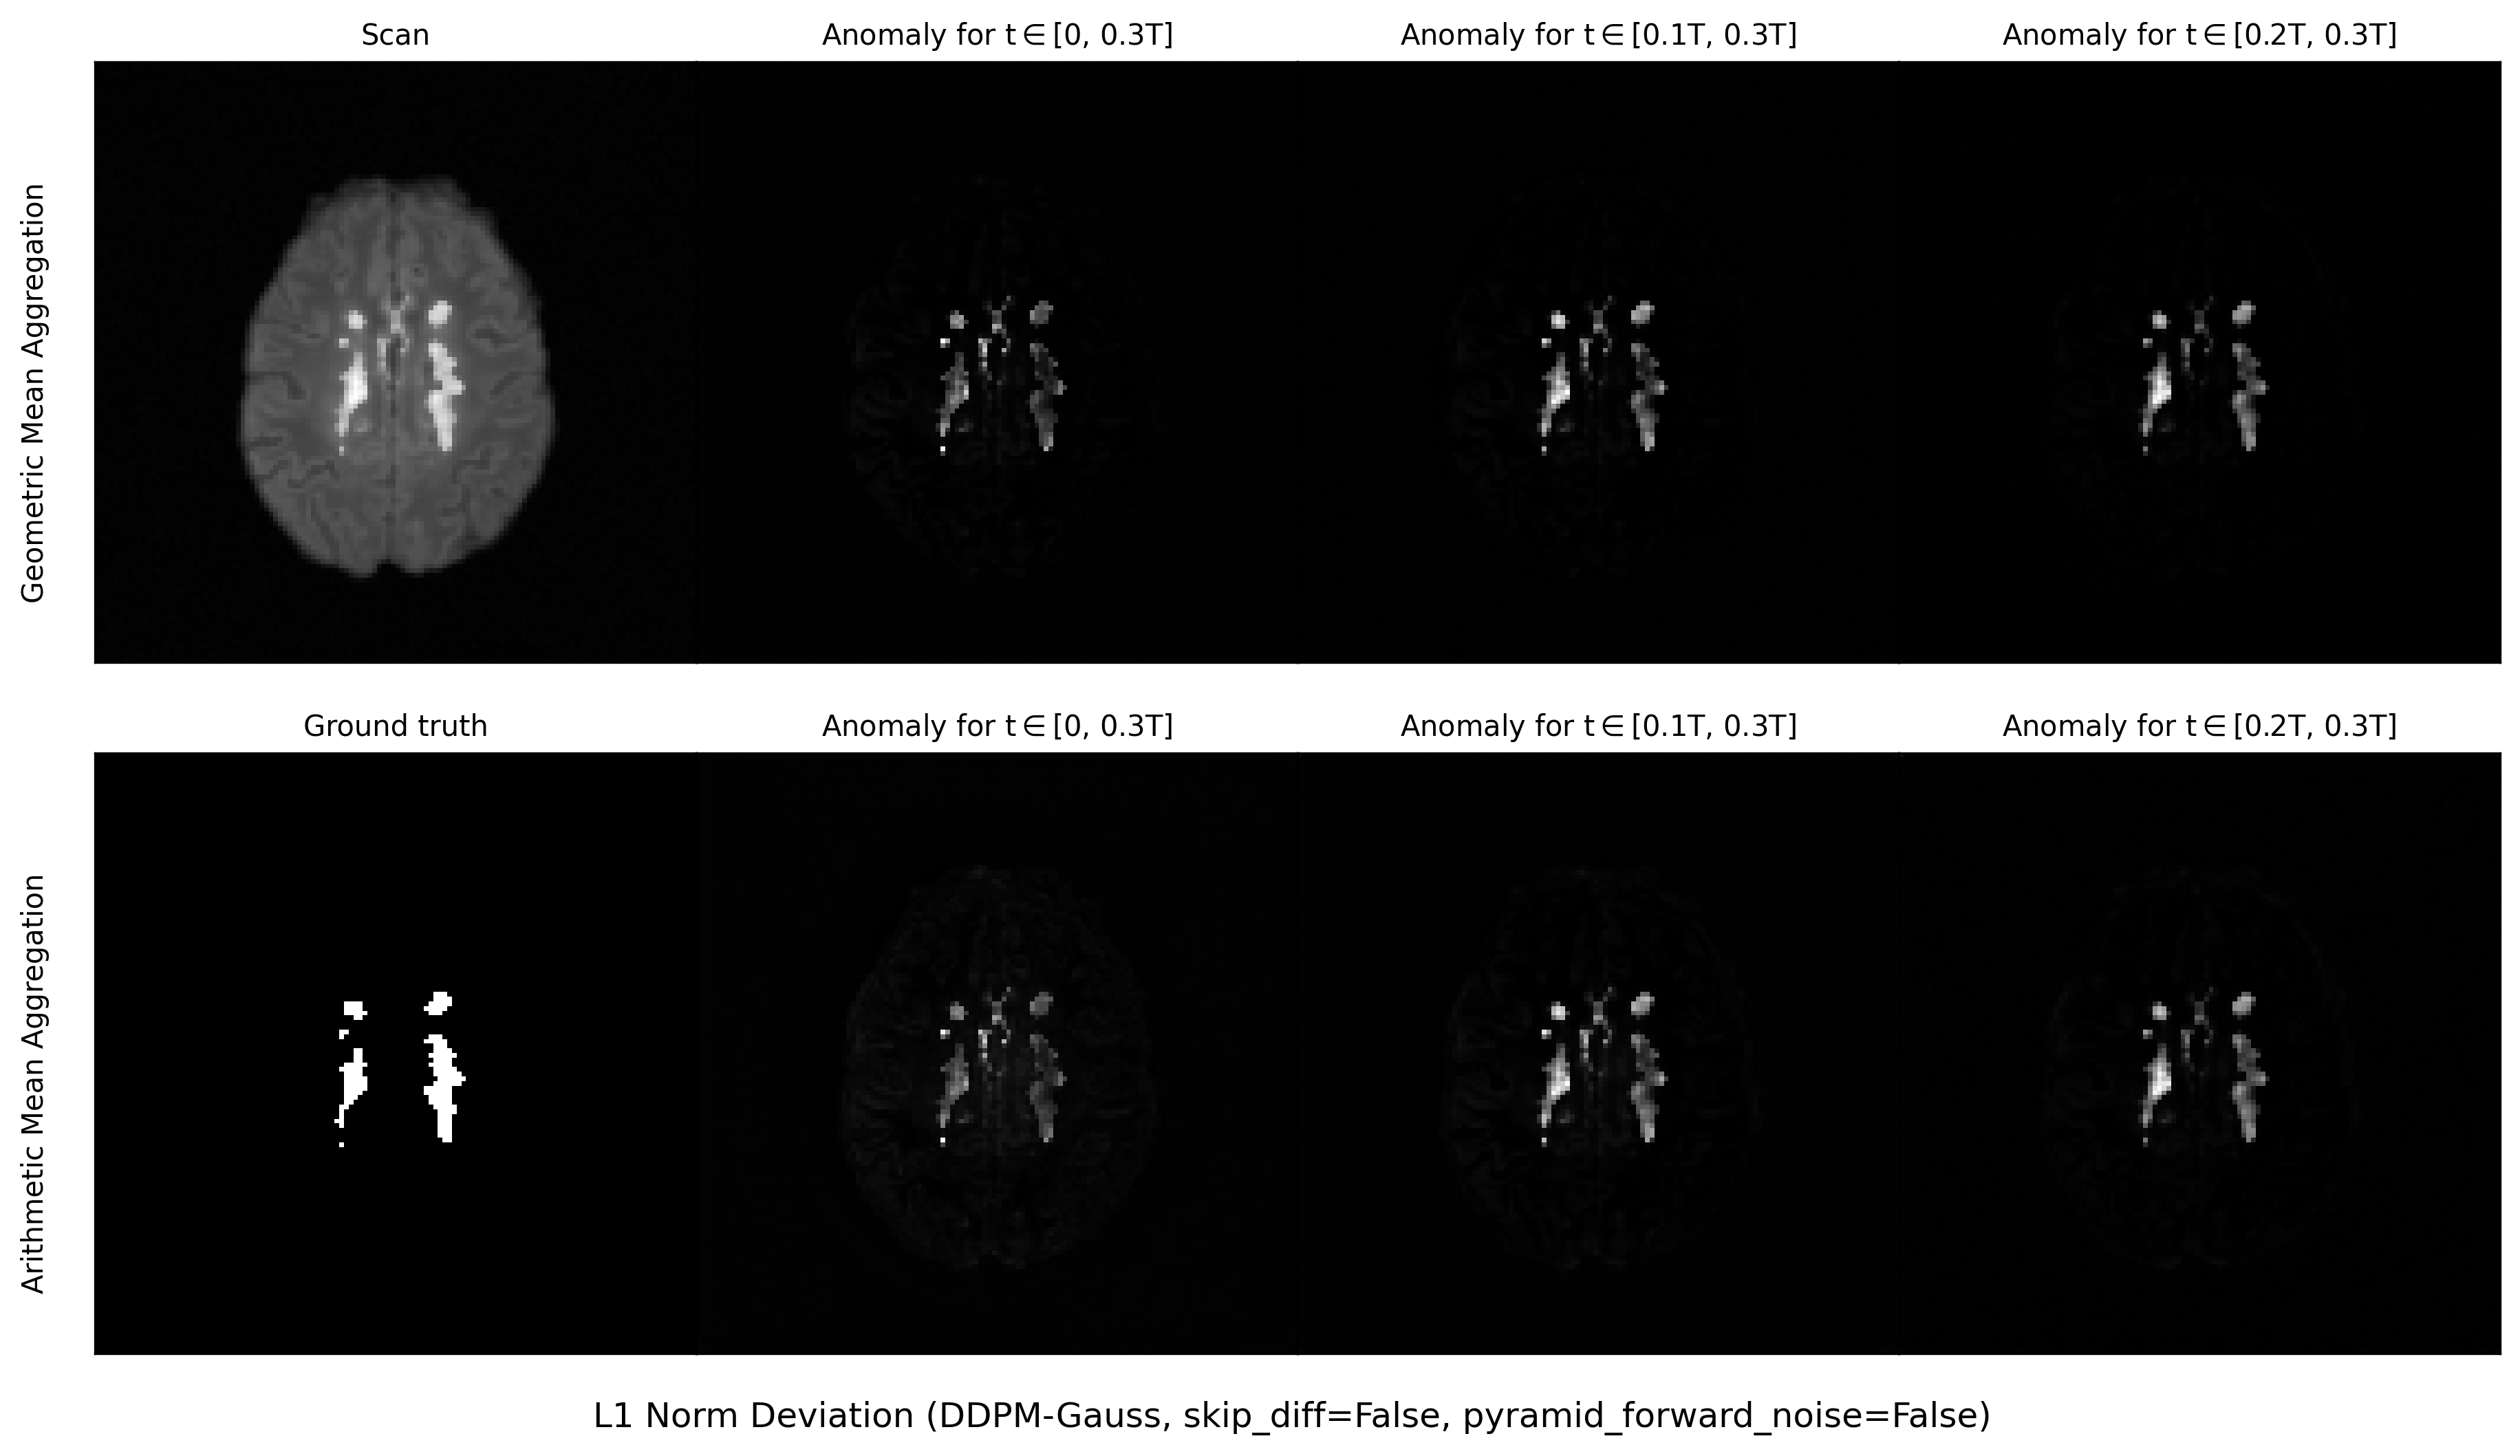

In [44]:
slice_loc = 100

val_to_plot = (pred_chain[slice_loc,:,0]-real_chain[slice_loc,:,0]).abs()**2

use_gm = False

seg = label.cpu()[0,:,:,slice_loc].cpu()

if use_gm:
    val_to_plot = val_to_plot.log()

# cumsum along axis 0 of val_to_plot (in reverse order), then reverse the result
val_to_plot = val_to_plot.flip(dims=(0,)).cumsum(dim=0).flip(dims=(0,))
print(val_to_plot.shape, torch.arange(1, val_to_plot.shape[0] + 1).flip(dims=(0,)).to(val_to_plot.device).float().shape)
# then scale down the cumsum axis with numbers that are summed over
val_to_plot = val_to_plot / torch.arange(1, val_to_plot.shape[0] + 1).flip(dims=(0,)).to(val_to_plot.device).float().unsqueeze(1).unsqueeze(2)

if use_gm:
   val_to_plot = torch.exp(val_to_plot)

# Set up the figure and subplots
fig, axs = plt.subplots(2, 4, figsize=(12, 7), dpi=300)  # Adjust figsize as needed to preserve aspect ratio
# set font size
plt.rcParams.update({'font.size': 10})

# The `vmin` and `vmax` arguments set the color scale. We find the global min and max across all subplots.
vmin = val_to_plot.min()
vmax = val_to_plot.max()

# A list of times to plot
times_to_plot = [299, 0, 100, 200]
titles = ['Ground truth', r'Anomaly for t$\in$[0, 0.3T]', r'Anomaly for t$\in$[0.1T, 0.3T]', r'Anomaly for t$\in$[0.2T, 0.3T]',]#[::-1]

# Plot each of the subplots
for ax, time, title in zip(axs[1], times_to_plot, titles):
    if time == 299:
        im = ax.imshow(seg.T, cmap='gray', vmin=0, vmax=1, aspect='equal')
    else:
        # im = ax.imshow(val_to_plot[time, :, :].T, cmap='gray', vmin=vmin, vmax=vmax, aspect='equal')
        im = ax.imshow(val_to_plot[time, :, :].T, cmap='gray', aspect='equal')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])



val_to_plot = (pred_chain[slice_loc,:,0]-real_chain[slice_loc,:,0]).abs()**2
seg = label.cpu()[0,:,:,slice_loc].cpu()

use_gm = True


if use_gm:
    val_to_plot = val_to_plot.log()

# cumsum along axis 0 of val_to_plot (in reverse order), then reverse the result
val_to_plot = val_to_plot.flip(dims=(0,)).cumsum(dim=0).flip(dims=(0,))
print(val_to_plot.shape, torch.arange(1, val_to_plot.shape[0] + 1).flip(dims=(0,)).to(val_to_plot.device).float().shape)
# then scale down the cumsum axis with numbers that are summed over
val_to_plot = val_to_plot / torch.arange(1, val_to_plot.shape[0] + 1).flip(dims=(0,)).to(val_to_plot.device).float().unsqueeze(1).unsqueeze(2)

if use_gm:
    val_to_plot = torch.exp(val_to_plot)



# The `vmin` and `vmax` arguments set the color scale. We find the global min and max across all subplots.
vmin = val_to_plot.min()
vmax = val_to_plot.max()

# A list of times to plot
times_to_plot = [299, 0, 100, 200]
titles = ['Scan', r'Anomaly for t$\in$[0, 0.3T]', r'Anomaly for t$\in$[0.1T, 0.3T]', r'Anomaly for t$\in$[0.2T, 0.3T]',]#[::-1]

# Plot each of the subplots
for ax, time, title in zip(axs[0], times_to_plot, titles):
    if time == 299:
        im = ax.imshow(real_chain[slice_loc,0,0].T, cmap='gray', aspect='equal')
    else:
        # im = ax.imshow(val_to_plot[time, :, :].T, cmap='gray', vmin=vmin, vmax=vmax, aspect='equal')
        im = ax.imshow(val_to_plot[time, :, :].T, cmap='gray', aspect='equal')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

# Adjust layout to prevent overlap
fig.tight_layout()


# add sideways text to ax[0,0] and ax[1,0] like yticks
axs[1,0].text(-0.1, 0.8, 'Arithmetic Mean Aggregation', va='center', ha='right', rotation='vertical', rotation_mode='anchor', transform=axs[1,0].transAxes)
axs[0,0].text(-0.1, 0.8, 'Geometric Mean Aggregation', va='center', ha='right', rotation='vertical', rotation_mode='anchor', transform=axs[0,0].transAxes)
# # Create an axis for the colorbar
# cbar_ax = fig.add_axes([1.0, 0.15, 0.03, 0.7])
# fig.colorbar(im, cax=cbar_ax)


# zero horizontal space between plots
plt.subplots_adjust(wspace=0, hspace=0)

fig.suptitle('L1 Norm Deviation (DDPM-Gauss, skip_diff=False, pyramid_forward_noise=False)', y=0.02)

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import torch

def plot_images_subplot(image_list, titles_list, suptitle, use_gm):
    # ensure the image_list has 12 elements for the 3x4 grid
    assert len(image_list) == 12, "image_list must contain 12 images."
    assert len(titles_list) == 12, "titles_list must contain 12 titles."
    
    # set up the figure and subplots
    fig, axs = plt.subplots(3, 4, figsize=(16, 12), dpi=300) # adjust figsize to preserve aspect ratio
    
    # set font size and font type to arial
    plt.rcParams.update({'font.size': 10, 'font.family': 'Arial'})
    
    # loop over the grid and populate the subplots
    for idx, (ax, image, title) in enumerate(zip(axs.flat, image_list, titles_list)):
        # plot image in grayscale
        im = ax.imshow(image.T, cmap='gray', aspect='equal')
        
        # set title for each subplot
        ax.set_title(title, fontsize=10)
        
        # remove x and y ticks
        ax.set_xticks([])
        ax.set_yticks([])
        
        # add text to the first column subplots to denote the mean aggregation type
        if idx % 4 == 0:
            mean_type = 'Arithmetic Mean Aggregation' if not use_gm else 'Geometric Mean Aggregation'
            ax.text(-0.1, 0.5, mean_type, va='center', ha='right', rotation='vertical', 
                    rotation_mode='anchor', transform=ax.transAxes)
    
    # adjust layout to prevent overlap
    fig.tight_layout()
    
    # set suptitle for the figure
    fig.suptitle(suptitle, y=0.02)
    
    # zero horizontal space between plots
    plt.subplots_adjust(wspace=0, hspace=0)
    
    # display the figure
    plt.show()

    return fig  # return the figure object for further manipulation if needed

# Example usage:


image_list = 

plot_images_subplot(image_list, titles_list, 'My Suptitle', use_gm)


In [ ]:

# Assume pred_chain and real_chain are available as 4D tensors (slice, time, channel, height, width)
# Assume label is available as a 4D tensor (batch, channel, height, width, slice)
# Below is the code adapted for animation:

# Setup figure and axes
fig, axs = plt.subplots(2, 4, figsize=(12, 7), dpi=300)
plt.rcParams.update({'font.size': 10})

# Titles for subplots
titles_am = ['Arithmetic Mean Aggregation', r'Anomaly for t$\in$[0, 0.3T]', r'Anomaly for t$\in$[0.1T, 0.3T]', r'Anomaly for t$\in$[0.2T, 0.3T]']
titles_gm = ['Geometric Mean Aggregation', r'Anomaly for t$\in$[0, 0.3T]', r'Anomaly for t$\in$[0.1T, 0.3T]', r'Anomaly for t$\in$[0.2T, 0.3T]']

# Initial setup for images, to be used in the animation
ims_am = []
ims_gm = []

# Create a function to update the content of the subplots for each frame
def update(frame):
    # Clear previous images
    for im in ims_am + ims_gm:
        im.remove()

    ims_am.clear()
    ims_gm.clear()

    # Calculate the values to plot
    for use_gm, axs_row, titles in zip([False, True], axs, [titles_am, titles_gm]):
        val_to_plot = (pred_chain[frame, :, 0] - real_chain[frame, :, 0]).abs() ** 2

        if use_gm:
            val_to_plot = val_to_plot.log()

        # cumsum along axis 0 of val_to_plot (in reverse order), then reverse the result
        val_to_plot = val_to_plot.flip(dims=(0,)).cumsum(dim=0).flip(dims=(0,))
        # Scale down the cumsum axis with numbers that are summed over
        val_to_plot = val_to_plot / torch.arange(1, val_to_plot.shape[0] + 1).flip(dims=(0,)).to(val_to_plot.device).float().unsqueeze(1).unsqueeze(2)

        if use_gm:
            val_to_plot = torch.exp(val_to_plot)

        # Set the color scale.
        vmin = val_to_plot.min()
        vmax = val_to_plot.max()

        # Plot each of the subplots for arithmetic and geometric mean
        for ax, time, title in zip(axs_row, [299, 0, 100, 200], titles):
            if time == 299:
                if use_gm:
                    im = ax.imshow(real_chain[frame, 0, 0].T, cmap='gray', aspect='equal')
                    title = 'Slice'
                else:
                    im = ax.imshow(label.cpu()[0, :, :, frame].cpu().T, cmap='gray', vmin=0, vmax=1, aspect='equal')
                    title = 'Ground Truth'
            else:
                im = ax.imshow(val_to_plot[time, :, :].T, cmap='gray', vmin=vmin, vmax=vmax, aspect='equal')
            
            ax.set_title(title, fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])

            if use_gm:
                ims_gm.append(im)
            else:
                ims_am.append(im)

    # Add the sideways text for yticks
    axs[1, 0].text(-0.1, 0.8, titles_am[0], va='center', ha='right', rotation='vertical', rotation_mode='anchor', transform=axs[1, 0].transAxes)
    axs[0, 0].text(-0.1, 0.8, titles_gm[0], va='center', ha='right', rotation='vertical', rotation_mode='anchor', transform=axs[0, 0].transAxes)

    # Adjust layout to prevent overlap
    fig.tight_layout()

# Create the animation
ani = FuncAnimation(fig, update, frames=range(155), blit=False)

# Save the animation
ani.save('deviation_animation.mp4', writer='ffmpeg', dpi=300)

# Display the animation
Video('deviation_animation.mp4')

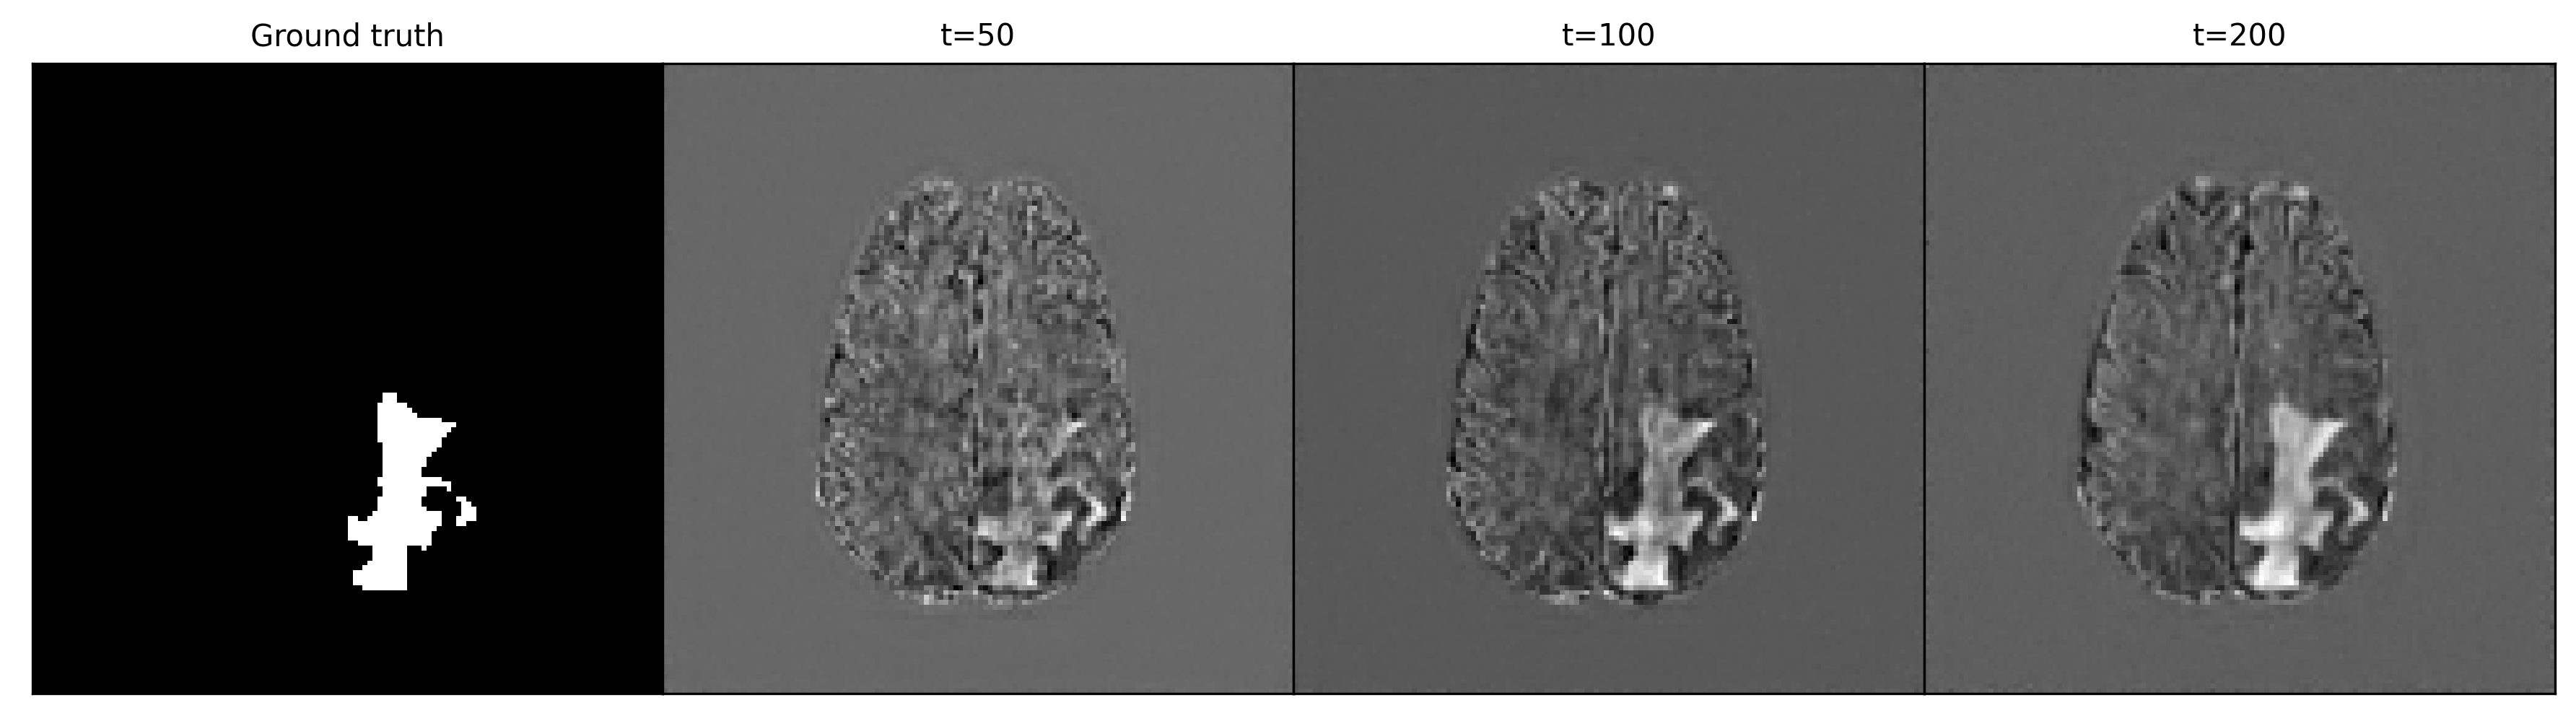

In [109]:
# val_to_plot = (pred_chain[100,:,0]-real_chain[100,:,0]).abs()
# val_to_plot = pred_chain[100,:,0]
# val_to_plot = real_chain[100,:,0]
val_to_plot = real_chain[100,:,0]-pred_chain[100,:,0]

use_gm = False

seg = label.cpu()[0,:,:,100].cpu()


# Set up the figure and subplots
fig, axs = plt.subplots(1, 4, figsize=(12, 4), dpi=300)  # Adjust figsize as needed to preserve aspect ratio
# set font size
plt.rcParams.update({'font.size': 10})

# The `vmin` and `vmax` arguments set the color scale. We find the global min and max across all subplots.
vmin = val_to_plot.min()
vmax = val_to_plot.max()

# A list of times to plot
times_to_plot = [0, 50, 100, 200]
# titles = ['Ground truth', r'Anomaly for t$\in$[0, 0.3T]', r'Anomaly for t$\in$[0.1T, 0.3T]', r'Anomaly for t$\in$[0.2T, 0.3T]',]#[::-1]

# Plot each of the subplots
for ax, t in zip(axs, times_to_plot):
    img = val_to_plot[t].T
    title = f't={t}'
    if t==0:
        img = seg.T
        title = 'Ground truth'
    # im = ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax, aspect='equal')
    im = ax.imshow(img, cmap='gray', aspect='equal')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])


# Adjust layout to prevent overlap
fig.tight_layout()

# zero horizontal space between plots
plt.subplots_adjust(wspace=0, hspace=0)

plt.show()


tensor[128, 128] bool n=16384 x∈[False, True] μ=0.028 σ=0.164

In [ ]:
# torch.Size([155, 299, 4, 128, 128])

## Precomputing the zs and the predicted and real backward chains for differnet cases

In [ ]:
model, dataloader = accelerator.prepare(model, dataloader)
pbar = tqdm(dataloader)

with torch.no_grad():
    my_volume = torch.zeros(
        (
            1,
            4,
            128,
            128,
            155,
        )
    ).to("cpu")
    my_labels = (
        torch.zeros(
            (
                1,
                128,
                128,
                155,
            )
        )
        .type(torch.bool)
        .to("cpu")
    )
    for i, (image, label) in enumerate(pbar):
        image = (image * 2) - 1
        num_steps = 200
        size_splits = 50
        num_volumes = image.shape[0]
        num_slices = image.shape[4]

        image = torch.permute(image, (0, 4, 1, 2, 3))
        image = image.view(-1, image.shape[2], image.shape[3], image.shape[4])
        split = torch.split(image, size_splits)
        zs_list = []
        for my_tensor in split:
            # zs = diffusion.dpm_differences(model, my_tensor, start=100, stop=num_steps, pyramid=True).to('cpu')
            zs = diffusion.skip_differences(model, my_tensor, start = 100, stop = num_steps, skip=25, pyramid=True).to('cpu')
            # zs = diffusion.differences_noise(model, my_tensor, start = 100, stop = num_steps, pyramid=False).to('cpu')
            zs_list.append(zs)

        zs_list = torch.cat(zs_list, dim=0)

In [ ]:
ckpt = torch.load(
    "data/brats/models/DDPM-Pyramid/232_ema_ckpt.pt" # Gaussian noise
    # "data/brats/models/DDPM-Pyramid/232_ema_ckpt.pt" # Pyramidal noise
)

model.load_state_dict(ckpt)
model.eval()

args = shiftsargs
diffusion = Diffusion(noise_steps=1000, img_size=128, device=device)
dataloader = MRI_Volume(args, hist=False, shift=True)


model, dataloader = accelerator.prepare(model, dataloader)
pbar = tqdm(dataloader)
threshold_test = [round(x, 3) for x in np.arange(0.01, 0.99, 0.01)]

max_dice = []
for start in [100]:
    dice_scores_mask = {i: [] for i in threshold_test}
    with torch.no_grad():
        my_volume = torch.zeros(
            (
                1,
                4,
                128,
                128,
                155-60,
            )
        ).to("cpu")
        my_labels = (
            torch.zeros(
                (
                    1,
                    128,
                    128,
                    155-60,
                )
            )
            .type(torch.bool)
            .to("cpu")
        )
        for i, (image, label) in enumerate(pbar):

            if i > 2:
                break 
            
            print(image.shape)

            ## histogram matching
            image = torch.from_numpy(match_histograms_vectorized(image.cpu().numpy(), template.numpy())).to(device).float()

            image = (image * 2) - 1

            # remove the bottom slices
            image = image[:,:,:,:,60:]
            label = label[:,:,:,60:]

            # start = 300
            num_steps = 300
            size_splits = 50
            num_volumes = image.shape[0]
            num_slices = image.shape[4]

            image = torch.permute(image, (0, 4, 1, 2, 3))
            image = image.view(-1, image.shape[2], image.shape[3], image.shape[4])
            split = torch.split(image, size_splits)
            zs_list = []
            for my_tensor in split:
                zs = diffusion.dpm_differences(model, my_tensor, start=start, stop=num_steps+start, pyramid=False, l2=False).to('cpu')
                # zs = diffusion.skip_differences(model, my_tensor, start = 100, stop = num_steps, skip=25, pyramid=True).to('cpu')
                # zs = diffusion.differences_noise(model, my_tensor, start = 100, stop = num_steps, pyramid=False).to('cpu')
                zs_list.append(zs)

            zs_list = torch.cat(zs_list, dim=0)
            my_mean = gmean(zs_list,dim=1)

            my_mean = my_mean.view(
                num_volumes,
                num_slices,
                my_mean.shape[1],
                my_mean.shape[2],
                my_mean.shape[3],
            )
            my_mean = torch.permute(my_mean, (0, 2, 3, 4, 1))
            my_mean = my_mean.to(device)
            my_mean, label = accelerator.gather_for_metrics((my_mean, label))
            my_labels = torch.cat((my_labels, label.to("cpu")), dim=0)
            my_volume = torch.cat((my_volume, my_mean.to("cpu")), dim=0)

        if not torch.count_nonzero(my_labels[0]):
            my_labels = my_labels[1:]
            my_volume = my_volume[1:]
        my_mask = torch.max(my_volume, dim=1)[0]
        my_mask = median_filter_3D(my_mask)
        # my_mask = my_dilation(my_mask,kernelsize=3)
        my_labels = my_labels.contiguous()
        my_mask = norm_tensor(my_mask)
        my_mask = my_mask.contiguous()
        aupr = average_precision_score(my_labels.view(-1), my_mask.view(-1))
        for key in dice_scores_mask:
            segmentation = torch.where(my_mask > key, 1.0, 0.0)
            segmentation = segmentation.type(torch.bool)
            dice_scores_mask[key].extend([float(x) for x in dice(segmentation, my_labels)])
            dice_scores_mask[key] = np.mean(np.asarray(dice_scores_mask[key]))

        dice_scores_mask[f"AUPRC"] = aupr
        df_mask = pd.DataFrame(dice_scores_mask, index=[0]).T
        # print(df_mask)
        print(df_mask[0].values[:-1].max())
        max_dice.append(df_mask[0].values[:-1].max())

print(max_dice)

In [57]:
dice_scores_mask = {i: [] for i in threshold_test}

if not torch.count_nonzero(my_labels[0]):
    my_labels = my_labels[1:]
    my_volume = my_volume[1:]
my_mask = torch.max(my_volume[:,[0]], dim=1)[0]
# my_mask = median_filter_3D(my_mask)
# my_mask = my_dilation(my_mask,kernelsize=3)
my_labels = my_labels.contiguous()
my_mask = norm_tensor(my_mask)
my_mask = my_mask.contiguous()
aupr = average_precision_score(my_labels.view(-1), my_mask.view(-1))
for key in dice_scores_mask:
    segmentation = torch.where(my_mask > key, 1.0, 0.0)
    segmentation = segmentation.type(torch.bool)
    dice_scores_mask[key].extend([float(x) for x in dice(segmentation, my_labels)])
    dice_scores_mask[key] = np.mean(np.asarray(dice_scores_mask[key]))

dice_scores_mask[f"AUPRC"] = aupr
df_mask = pd.DataFrame(dice_scores_mask, index=[0]).T
# print(df_mask)
print(df_mask[0].values[:-1].max())
print(df_mask[0].values[-1])


0.3639643316467603
0.3488316816472965


In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(9, 3))

# Create two subplots: one for the mask and one for the labels
ims = []
for i in range(my_mask.shape[-1]):  # Assuming the last dimension size is 156
    im_mask = axs[0].imshow(my_mask[0, :, :, i], vmin=my_mask[0].min(), vmax=my_mask[0].max(), cmap='gray', animated=True)
    im_mask_thresh = axs[1].imshow(my_mask[0, :, :, i] > 0.35, cmap='gray', animated=True)
    im_labels = axs[2].imshow(my_labels[0, :, :, i], cmap='gray', animated=True)
    # add title for each subplot
    axs[0].set_title('predicted')
    axs[1].set_title('predicted thresh')
    axs[2].set_title('gt')
    # remove ticks
    axs[0].set_xticks([])
    axs[0].set_yticks([])
    axs[1].set_xticks([])
    axs[1].set_yticks([])
    axs[2].set_xticks([])
    axs[2].set_yticks([])
    ims.append([im_mask, im_mask_thresh, im_labels])
    
from matplotlib import animation
ani = animation.ArtistAnimation(fig, ims, interval=50, blit=True, repeat_delay=1000)

# To display the animation in a Jupyter notebook, you would use the following:
# from IPython.display import HTML
# HTML(ani.to_jshtml())

# Since we cannot display the animation directly here, we'll save it as a gif
ani.save('mask_labels_animation.mp4', writer='imagemagick', dpi=80)

plt.close(fig)  # Close the figure to prevent it from displaying statically
# Display the animation
from IPython.display import Video
Video('mask_labels_animation.mp4')



In [ ]:
plt.imshow(my_mask[0,:,:,100]>0.09, cmap='gray')
plt.show()
plt.imshow(my_labels[0,:,:,100], cmap='gray')
plt.show()

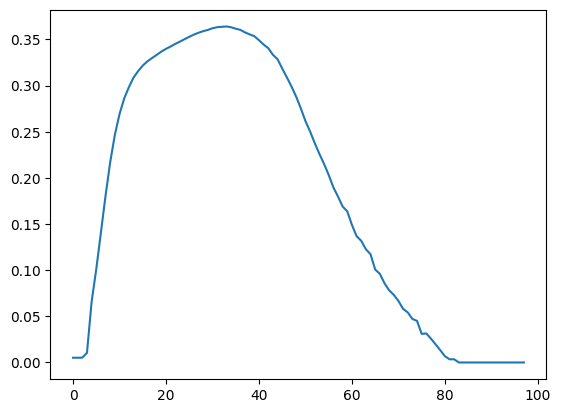

In [54]:
plt.plot(df_mask[0].values[:-1])

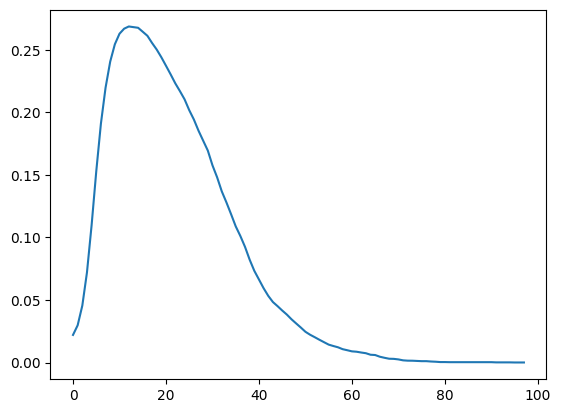

In [52]:
plt.plot(df_mask[0].values[:-1])

In [ ]:
threshold_test = [round(x, 3) for x in np.arange(0.01, 0.3, 0.01)]
dice_scores_mask = {i: [] for i in threshold_test}

if accelerator.is_main_process:
    if not torch.count_nonzero(my_labels[0]):
        my_labels = my_labels[1:]
        my_volume = my_volume[1:]
    my_mask = torch.max(my_volume, dim=1)[0]
    my_mask = median_filter_3D(my_mask)
    # my_mask = my_dilation(my_mask,kernelsize=3)
    my_labels = my_labels.contiguous()
    my_mask = norm_tensor(my_mask)
    my_mask = my_mask.contiguous()
    aupr = average_precision_score(my_labels.view(-1), my_mask.view(-1))
    for key in dice_scores_mask:
        segmentation = torch.where(my_mask > key, 1.0, 0.0)
        segmentation = segmentation.type(torch.bool)
        dice_scores_mask[key].extend([float(x) for x in dice(segmentation, my_labels)])
        dice_scores_mask[key] = np.mean(np.asarray(dice_scores_mask[key]))

    dice_scores_mask[f"AUPRC"] = aupr
    df_mask = pd.DataFrame(dice_scores_mask, index=[0]).T
    print(df_mask)

## simplex eval

In [51]:

import argparse

from accelerate import Accelerator, DistributedDataParallelKwargs
from sklearn.metrics import average_precision_score
from skimage.filters import threshold_yen
from scipy.ndimage import generate_binary_structure
from diffusion import *
from modules import *
from utils import *

args = argparse.Namespace()

torch.manual_seed(73)

args.dataset_path = "data/brats"
args.path_to_csv = "data/brats/splits/scans_test.csv"
args.batch_size = 1
args.image_size = 128

kwargs = DistributedDataParallelKwargs(find_unused_parameters=True)
accelerator = Accelerator(kwargs_handlers=[kwargs])
device = accelerator.device
model = UNet().to(device=device)
print(f"loading model")
ckpt = torch.load(f"/home/ubuntu/slurm_work/repos/normative-diffusion/models/Brats128_simplex/208_ema_ckpt.pt")

model.load_state_dict(ckpt)
diffusion = Diffusion(noise_steps=1000, img_size=128, device=device)
print("Loading dataset...")
dataloader = MRI_Volume(
    args, hist=False, shift=False
)

model, dataloader = accelerator.prepare(model, dataloader)
pbar = tqdm(dataloader)
threshold_test = [round(x, 3) for x in np.arange(0.01, 0.10, 0.001)]
dice_scores_mask = {i: [] for i in threshold_test}
dice_scores_mask_median = {i: [] for i in threshold_test}
my_auprs = {i: [] for i in ["aupr no median", "aupr"]}

    # my_volume = torch.zeros(
    #     (
    #         1,
    #         4,
    #         128,
    #         128,
    #         155,
    #     )
    # ).to("cpu")
    # my_labels = (
    #     torch.zeros(
    #         (
    #             1,
    #             128,
    #             128,
    #             155,
    #         )
    #     )
    #     .type(torch.bool)
    #     .to("cpu")
    # )

    # for i, (image, label) in enumerate(pbar):
    #     image = (image * 2) - 1
    #     num_steps = 200
    #     size_splits = 200
    #     num_volumes = image.shape[0]
    #     num_slices = image.shape[4]

    #     image = torch.permute(image, (0, 4, 1, 2, 3))
    #     image = image.view(-1, image.shape[2], image.shape[3], image.shape[4])



        # split = torch.split(image, size_splits)
    #     zs_list = []
    #     for my_tensor in split:
    #         zs = diffusion.dpm_differences(
    #             model, my_tensor, start=75, stop=num_steps, pyramid=False, simplex=True
    #         ).to("cpu")
    #         # zs = diffusion.skip_differences(model, my_tensor, start = 100, stop = num_steps, skip=25, pyramid=False).to('cpu')
    #         # zs = diffusion.differences_noise(model, my_tensor, start = 100, stop = num_steps, pyramid=False).to('cpu')
    #         zs_list.append(zs)

    #     zs_list = torch.cat(zs_list, dim=0)
    #     my_mean = gmean(zs_list, dim=1)
    #     # my_mean = torch.mean(zs_list,dim=1)

    #     my_mean = my_mean.view(
    #         num_volumes,
    #         num_slices,
    #         my_mean.shape[1],
    #         my_mean.shape[2],
    #         my_mean.shape[3],
    #     )
    #     my_mean = torch.permute(my_mean, (0, 2, 3, 4, 1))
    #     my_mean = my_mean.to(device)
    #     my_mean, label = accelerator.gather_for_metrics((my_mean, label))
    #     my_labels = torch.cat((my_labels, label.to("cpu")), dim=0)
    #     my_volume = torch.cat((my_volume, my_mean.to("cpu")), dim=0)
    #     # break

    # if accelerator.is_main_process:
    #     if not torch.count_nonzero(my_labels[0]):
    #         my_labels = my_labels[1:]
    #         my_volume = my_volume[1:]
    #     my_mask = torch.max(my_volume, dim=1)[0]
    #     mask_median = torch.clone(my_mask)
    #     mask_median = median_filter_3D(mask_median, kernelsize=5)
    #     my_labels = my_labels.contiguous()
    #     my_mask = norm_tensor(my_mask)
    #     mask_median = norm_tensor(mask_median)

    #     my_mask = my_mask.contiguous()
    #     mask_median = mask_median.contiguous()
    #     aupr = average_precision_score(my_labels.view(-1), my_mask.view(-1))
    #     my_auprs["aupr no median"].extend([aupr])
    #     aupr = average_precision_score(my_labels.view(-1), mask_median.view(-1))
    #     my_auprs["aupr"].extend([aupr])
    #     for key in dice_scores_mask:
    #         segmentation = torch.where(my_mask > key, 1.0, 0.0)
    #         segmentation = segmentation.type(torch.bool)
    #         my_mask2 = torch.where(mask_median > key, 1.0, 0.0)
    #         my_mask2 = my_mask2.type(torch.bool)
    #         dice_scores_mask[key].extend(
    #             [float(x) for x in dice(segmentation, my_labels)]
    #         )
    #         dice_scores_mask[key] = np.mean(np.asarray(dice_scores_mask[key]))
    #         dice_scores_mask_median[key].extend(
    #             [float(x) for x in dice(my_mask2, my_labels)]
    #         )
    #         dice_scores_mask_median[key] = np.mean(
    #             np.asarray(dice_scores_mask_median[key])
    #         )

    #     big_segmentation = torch.zeros_like(my_mask)
    #     struc = generate_binary_structure(3, 1)

    #     for j, volume in enumerate(my_mask):
    #         thr = threshold_yen(volume.numpy())
    #         segmentation = torch.where(volume > thr, 1.0, 0.0)
    #         big_segmentation[j] = segmentation
    #     big_segmentation = bin_dilation(big_segmentation, struc)
    #     dice_scores_mask["yen"] = []
    #     dice_scores_mask["yen"].extend(
    #         [float(x) for x in dice(big_segmentation, my_labels)]
    #     )
    #     dice_scores_mask["yen"] = np.mean(np.asarray(dice_scores_mask["yen"]))

    #     for j, volume in enumerate(mask_median):
    #         thr = threshold_yen(volume.numpy())
    #         segmentation = torch.where(volume > thr, 1.0, 0.0)
    #         big_segmentation[j] = segmentation
    #     big_segmentation = bin_dilation(big_segmentation, struc)
    #     dice_scores_mask_median["yen"] = []
    #     dice_scores_mask_median["yen"].extend(
    #         [float(x) for x in dice(big_segmentation, my_labels)]
    #     )
    #     dice_scores_mask_median["yen"] = np.mean(
    #         np.asarray(dice_scores_mask_median["yen"])
    #     )

    #     dice_scores_mask["AUPRC"] = np.asarray(my_auprs["aupr no median"])
    #     dice_scores_mask_median["AUPRC"] = np.asarray(my_auprs["aupr"])
    #     df_mask = pd.DataFrame(dice_scores_mask, index=[0]).T
    #     df_mask2 = pd.DataFrame(dice_scores_mask_median, index=[0]).T
    #     df_mask.to_csv(f"{args.model}_{args.data}_pyr_brats_mask_3D.csv")
    #     df_mask2.to_csv(f"{args.model}_{args.data}_pyr_brats_mask_median.csv")



loading model
Loading dataset...


  0%|          | 0/251 [00:00<?, ?it/s]

In [56]:
# sample
ema_sampled_images = [diffusion.simplex_sample(
    model,
    n=1,
    labels=None,
    channels=4,
    cfg_scale=0,
    pyramid=False,
    simplex=True,
    ) for _ in range(5)]
    


999it [00:47, 20.98it/s]
999it [00:47, 20.84it/s]
999it [00:47, 21.25it/s]
999it [00:47, 21.09it/s]
999it [00:48, 20.67it/s]


In [59]:
ema_sampled_images = torch.cat(ema_sampled_images, dim=0)

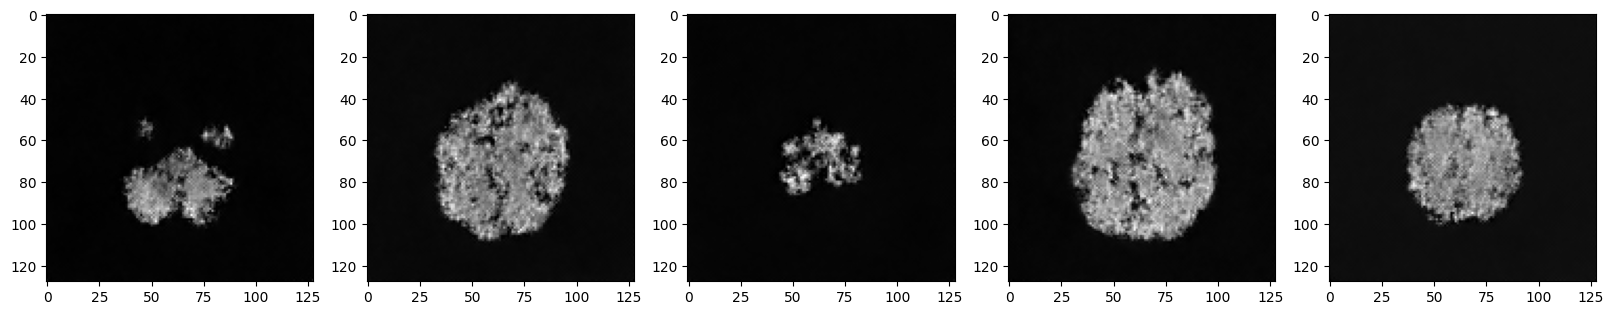

In [60]:
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    axs[i].imshow(ema_sampled_images[i,0].cpu().numpy().T, cmap='gray')
plt.show()


In [55]:
ema_sampled_images[i,0].flatten().shape

torch.Size([16384])

torch.Size([1, 8, 128, 128])
2 0.07745075225830078
torch.Size([1, 16, 128, 128])
4 0.15023541450500488
torch.Size([1, 32, 128, 128])
8 0.30120396614074707
torch.Size([1, 64, 128, 128])
16 0.6167538166046143
torch.Size([1, 128, 128, 128])
32 1.230973720550537
torch.Size([1, 256, 128, 128])
64 2.4932925701141357
torch.Size([1, 512, 128, 128])
128 5.006388902664185
torch.Size([1, 1024, 128, 128])
256 9.85208249092102


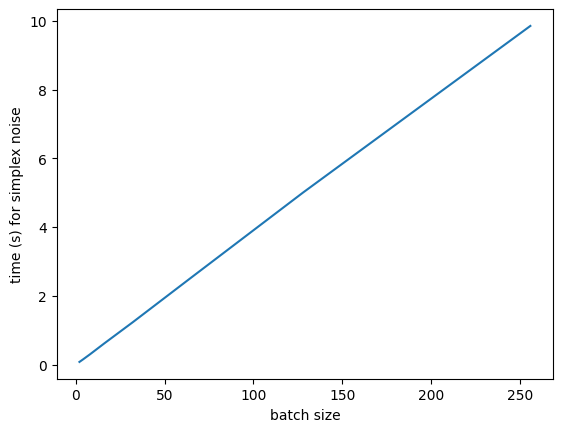

In [4]:
importbaselines import simplex_noise
import time
times = []
for batch_size in [2, 4, 8, 16, 32, 64, 128, 256]:
    tmp = torch.randn((batch_size, 4, 128, 128))
    bs = tmp.shape[0]
    #merge batch and channel
    tmp = tmp.view(-1, tmp.shape[2], tmp.shape[3]).unsqueeze(0)
    t = (torch.arange(1)  + 10).long()
    # print(tmp.shape, t.shape, t)
    time_start = time.time()
    x = simplex_noise.generate_simplex_noise(tmp, t, in_channels=tmp.shape[1])
    print(x.shape)
    times.append(time.time()-time_start)
    print(batch_size, times[-1])
    x = x.view(bs, x.shape[1]//bs, x.shape[2], x.shape[3])
plt.plot([2, 4, 8, 16, 32, 64, 128, 256], times)
plt.xlabel('batch size')
plt.ylabel('time (s) for simplex noise')
plt.show()

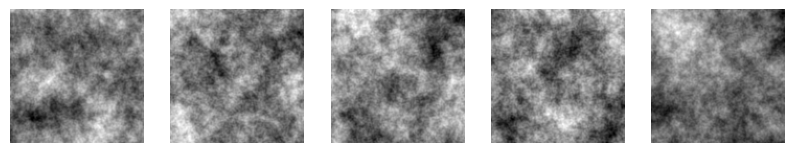

In [6]:
fig, ax = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    ax[i].imshow((x[i,0]).cpu().numpy().T, cmap='gray')
    ax[i].axis('off')

In [7]:
torch.randn(155, 4, 128, 128).view(-1, 128, 128).unsqueeze(0).shape

torch.Size([1, 620, 128, 128])

In [19]:
import baselines.simplex_noise

# precompute noise
time_start = time.time()
bs = 10
num_steps = 250
tmp = torch.zeros(bs, 4, 128, 128).cpu().repeat(num_steps, 1, 1, 1)
tmp = tmp.contiguous().view(-1, tmp.shape[2], tmp.shape[3]).unsqueeze(0)
t__ = (torch.arange(1) * 5).long()
batched_noise = baselines.simplex_noise.generate_simplex_noise(
    tmp, t__, in_channels=tmp.shape[1]
)
print(batched_noise.shape)
batched_noise = batched_noise.view(
    bs*num_steps,
    batched_noise.shape[1] // (bs*num_steps),
    batched_noise.shape[2],
    batched_noise.shape[3],
).unsqueeze(0)
batched_noise = batched_noise.view(
    num_steps,
    bs,
    batched_noise.shape[2],
    batched_noise.shape[3],
    batched_noise.shape[4],
)
print("time for simplex noise:", time.time() - time_start)

100%|██████████| 10000/10000 [01:39<00:00, 100.50it/s]

torch.Size([1, 10000, 128, 128])
torch.Size([1, 10000, 128, 128])
time for simplex noise: 99.61464595794678


In [24]:
torch.save(batched_noise, "data/simplex_noise.pt")

In [22]:
!ls

208_ema_ckpt.pt
328_ema_ckpt.pt
DDPM-Gauss_brats_pyr_brats_mask_3D.csv
DDPM-Gauss_brats_pyr_brats_mask_median.csv
DDPM-Gauss_shifts1_pyr_brats_mask_3D.csv
DDPM-Gauss_shifts1_pyr_brats_mask_median.csv
DDPM-Gauss_shifts2_pyr_brats_mask_3D.csv
DDPM-Gauss_shifts2_pyr_brats_mask_median.csv
DDPM-Pyramid_brats_pyr_brats_mask_3D.csv
DDPM-Pyramid_brats_pyr_brats_mask_median.csv
DDPM-Pyramid_shifts1_pyr_brats_mask_3D.csv
DDPM-Pyramid_shifts1_pyr_brats_mask_median.csv
DDPM-Pyramid_shifts2_pyr_brats_mask_3D.csv
DDPM-Pyramid_shifts2_pyr_brats_mask_median.csv
README.md
__pycache__
baselines
data
deviation_animation.mp4
diffusion.py
diffusion_jai.py
environment.yml
eval.py
eval_anoddpm.py
gaussian_distributions_with_fill.pdf
gaussian_distributions_without_fill.pdf
mask_labels_animation.gif
mask_labels_animation.mp4
modalities_animation.mp4
modules.py
noised_image_animation.mp4
notebooks
plots
prepare_data.py
pyr_pyr_brats_mask_3D.csv
pyr_pyr_brats_mask_median.csv
pyramidal_tensors.pdf
registrator.py


In [31]:

import torchvision.transforms.functional as TF

def random_transform_vectorized(tensor, target_size):
    # Randomly sample 620 distinct indices
    indices = torch.randperm(target_size)[:target_size]
    # Extract the slices
    sliced_tensor = tensor[:, indices, :, :]

    # Random rotations (0, 90, 180, 270 degrees) for the entire batch
    angles = torch.randint(0, 4, (sliced_tensor.size(1),)) * 90
    sliced_tensor = torch.stack([TF.rotate(sliced_tensor[:, i, :, :], angles[i].item()) 
                                 for i in range(sliced_tensor.size(1))])

    # Random horizontal flip for the entire batch
    flip_h = torch.rand(sliced_tensor.size(1)) < 0.5
    for i in range(sliced_tensor.size(1)):
        if flip_h[i]:
            sliced_tensor[:, i, :, :] = TF.hflip(sliced_tensor[:, i, :, :])

    # Random vertical flip for the entire batch
    flip_v = torch.rand(sliced_tensor.size(1)) < 0.5
    for i in range(sliced_tensor.size(1)):
        if flip_v[i]:
            sliced_tensor[:, i, :, :] = TF.vflip(sliced_tensor[:, i, :, :])

    return sliced_tensor


random_vectorized = random_transform_vectorized(x, 620)
random_vectorized.shape

torch.Size([620, 1, 128, 128])

In [29]:
x = torch.randn(1, 10000, 128, 128)